<a href="https://colab.research.google.com/github/Miguithub/SpotV2Net/blob/main/SpotV2Net_1m_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

---
# LIBRERIAS 1

In [ ]:
!pip install statsmodels

In [ ]:
import requests
import pandas as pd
import time
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

---

# DI

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
import pandas as pd

Mounted at /content/drive


In [ ]:
btc = pd.read_parquet('/content/drive/MyDrive/1mbtc.parquet')

In [ ]:
eth = pd.read_parquet('/content/drive/MyDrive/1meth.parquet')

In [ ]:
sol = pd.read_parquet('/content/drive/MyDrive/1msol.parquet')

Check

In [ ]:
btc.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2442120 entries, 0 to 2442119
Data columns (total 12 columns):
 #   Column                   Dtype         
---  ------                   -----         
 0   timestamp                datetime64[ns]
 1   btc_open                 float32       
 2   btc_high                 float32       
 3   btc_low                  float32       
 4   btc_close                float32       
 5   btc_volume               float32       
 6   btc_close_time           float32       
 7   btc_quote_asset_volume   float32       
 8   btc_num_trades           float32       
 9   btc_taker_buy_base_vol   float32       
 10  btc_taker_buy_quote_vol  float32       
 11  btc_ignore               float32       
dtypes: datetime64[ns](1), float32(11)
memory usage: 121.1 MB


In [ ]:
btc.tail()

,timestamp,open,high,low,close,volume,close_time,quote_asset_volume,num_trades,taker_buy_base_vol,taker_buy_quote_vol,ignore,hora_str,hora_time,hour,minute,second
2442115,2025-08-24 15:48:00,114542.632812,114562.406250,114517.609375,114517.609375,16.02561,1.756050e+12,1835723.25,2027.0,8.27439,9.477749e+05,0.0,15:48:00,15:48:00,15,48,0
2442116,2025-08-24 15:49:00,114517.617188,114533.328125,114482.773438,114533.320312,42.59750,1.756051e+12,4877514.00,1812.0,3.05036,3.493160e+05,0.0,15:49:00,15:49:00,15,49,0
2442117,2025-08-24 15:50:00,114533.320312,114551.312500,114533.320312,114551.296875,12.79862,1.756051e+12,1465999.00,658.0,10.24896,1.173940e+06,0.0,15:50:00,15:50:00,15,50,0
2442118,2025-08-24 15:51:00,114551.296875,114551.296875,114474.046875,114474.046875,10.90823,1.756051e+12,1249071.75,2916.0,0.69167,7.919539e+04,0.0,15:51:00,15:51:00,15,51,0
2442119,2025-08-24 15:52:00,114474.062500,114474.062500,114459.710938,114459.710938,13.82199,1.756051e+12,1582119.25,1216.0,2.56436,2.935275e+05,0.0,15:52:00,15:52:00,15,52,0


In [ ]:
eth.head()

,timestamp,open,high,low,close,volume,quote_asset_volume,num_trades,taker_buy_base_vol,taker_buy_quote_vol
0,2021-01-01 00:00:00,736.42,737.09,735.94,737.02,647.71994,476877.876291,359,484.87834,356959.311632
1,2021-01-01 00:01:00,737.12,739.00,737.06,738.74,1122.95415,828662.134054,643,801.45291,591231.725025
2,2021-01-01 00:02:00,738.78,738.81,737.35,737.82,418.49987,308922.657830,283,202.66306,149569.394165
3,2021-01-01 00:03:00,737.74,738.20,737.28,737.43,305.98424,225752.744573,251,235.36847,173656.181372
4,2021-01-01 00:04:00,737.38,737.80,736.80,736.89,350.36312,258306.222210,277,217.56157,160412.714708


Transformacion

In [ ]:
import numpy as np
import pandas as pd

cols_to_f32 = btc.select_dtypes(include=["float64", "int64"]).columns.tolist()
mem_before = btc.memory_usage(deep=True).sum()
btc[cols_to_f32] = btc[cols_to_f32].astype("float32")
mem_after = btc.memory_usage(deep=True).sum()

print(f"Columnas convertidas a float32: {len(cols_to_f32)}")
print(f"Memoria antes:  {mem_before/1024/1024:.2f} MB")
print(f"Memoria después:{mem_after/1024/1024:.2f} MB")

Columnas convertidas a float32: 11
Memoria antes:  363.32 MB
Memoria después:260.85 MB


In [ ]:
float32_cols = btc.select_dtypes(include=["float32"]).columns

btc.rename(
    columns={c: (c if c.startswith("btc_") else f"btc_{c}") for c in float32_cols},
    inplace=True
)
dupes = btc.columns[btc.columns.duplicated()].tolist()
if dupes:
    print("Advertencia: columnas duplicadas tras renombrar:", dupes)

In [ ]:
import pandas as pd
btc['timestamp'] = pd.to_datetime(btc['timestamp'], errors='coerce')

In [ ]:
import numpy as np
import pandas as pd

cols_to_f32 = eth.select_dtypes(include=["float64", "int64"]).columns.tolist()
mem_before = eth.memory_usage(deep=True).sum()
eth[cols_to_f32] = eth[cols_to_f32].astype("float32")
mem_after = eth.memory_usage(deep=True).sum()

print(f"Columnas convertidas a float32: {len(cols_to_f32)}")
print(f"Memoria antes:  {mem_before/1024/1024:.2f} MB")
print(f"Memoria después:{mem_after/1024/1024:.2f} MB")

Columnas convertidas a float32: 0
Memoria antes:  101.95 MB
Memoria después:101.95 MB


In [ ]:
float32_cols = eth.select_dtypes(include=["float32"]).columns

eth.rename(
    columns={c: (c if c.startswith("eth_") else f"eth_{c}") for c in float32_cols},
    inplace=True
)
dupes = eth.columns[eth.columns.duplicated()].tolist()
if dupes:
    print("Advertencia: columnas duplicadas tras renombrar:", dupes)

In [ ]:
import numpy as np
import pandas as pd

cols_to_f32 = sol.select_dtypes(include=["float64", "int64"]).columns.tolist()
mem_before = sol.memory_usage(deep=True).sum()
sol[cols_to_f32] = sol[cols_to_f32].astype("float32")
mem_after = sol.memory_usage(deep=True).sum()

print(f"Columnas convertidas a float32: {len(cols_to_f32)}")
print(f"Memoria antes:  {mem_before/1024/1024:.2f} MB")
print(f"Memoria después:{mem_after/1024/1024:.2f} MB")

Columnas convertidas a float32: 9
Memoria antes:  185.37 MB
Memoria después:101.95 MB


In [ ]:
float32_cols = sol.select_dtypes(include=["float32"]).columns

sol.rename(
    columns={c: (c if c.startswith("sol_") else f"sol_{c}") for c in float32_cols},
    inplace=True
)
dupes = sol.columns[sol.columns.duplicated()].tolist()
if dupes:
    print("Advertencia: columnas duplicadas tras renombrar:", dupes)

In [ ]:
import pandas as pd

# =========================
# 1) Normalizar y limpiar timestamps
# =========================
def _prep(df: pd.DataFrame, name: str) -> pd.DataFrame:
    if "timestamp" not in df.columns:
        raise KeyError(f"El DataFrame '{name}' no tiene columna 'timestamp'.")
    out = df.copy()

    # Asegurar dtype datetime64[ns] (naive)
    ts = pd.to_datetime(out["timestamp"], errors="coerce")
    # Si viene con tz, quitarla; si no, no pasa nada
    try:
        ts = ts.dt.tz_convert(None)
    except Exception:
        pass
    ts = ts.dt.tz_localize(None)
    out["timestamp"] = ts

    # Quitar nulos y duplicados de timestamp, y ordenar
    out = (
        out.dropna(subset=["timestamp"])
           .drop_duplicates(subset=["timestamp"], keep="last")
           .sort_values("timestamp")
    )
    return out

btc_ = _prep(btc, "btc")
eth_ = _prep(eth, "eth")
sol_ = _prep(sol, "sol")

# =========================
# 2) Evitar colisiones de nombres SIN prefijos/ sufijos
#    (Se preservan los nombres de ETH; se eliminan de btc/sol
#     las columnas que colisionan con ETH, excepto 'timestamp')
# =========================
overlap_btc = [c for c in btc_.columns if c != "timestamp" and c in eth_.columns]
overlap_sol = [c for c in sol_.columns if c != "timestamp" and c in eth_.columns]

btc_no_overlap = btc_.drop(columns=overlap_btc) if overlap_btc else btc_
sol_no_overlap = sol_.drop(columns=overlap_sol) if overlap_sol else sol_

# =========================
# 3) Merge anclado en ETH (timestamp principal)
# =========================
mf = (
    eth_
    .merge(btc_no_overlap, on="timestamp", how="left")
    .merge(sol_no_overlap, on="timestamp", how="left")
    .sort_values("timestamp")
    .reset_index(drop=True)
)

In [ ]:
mf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2429647 entries, 0 to 2429646
Data columns (total 30 columns):
 #   Column                   Dtype         
---  ------                   -----         
 0   timestamp                datetime64[ns]
 1   eth_open                 float32       
 2   eth_high                 float32       
 3   eth_low                  float32       
 4   eth_close                float32       
 5   eth_volume               float32       
 6   eth_quote_asset_volume   float32       
 7   eth_num_trades           float32       
 8   eth_taker_buy_base_vol   float32       
 9   eth_taker_buy_quote_vol  float32       
 10  btc_open                 float32       
 11  btc_high                 float32       
 12  btc_low                  float32       
 13  btc_close                float32       
 14  btc_volume               float32       
 15  btc_close_time           float32       
 16  btc_quote_asset_volume   float32       
 17  btc_num_trades           fl

In [ ]:
# Mantener solo 'timestamp' y columnas cuyo nombre termine en 'close' (insensible a mayúsculas)
import pandas as pd

if 'timestamp' not in mf.columns:
    raise KeyError("mf1 no tiene columna 'timestamp'.")

# Asegurar timestamp válido y ordenado
mf['timestamp'] = pd.to_datetime(mf1['timestamp'], errors='coerce')
mf1 = mf.dropna(subset=['timestamp']).sort_values('timestamp')

# Selección de columnas que terminan en 'close' (case-insensitive)
cols_close = [c for c in mf1.columns
              if c != 'timestamp' and c.strip().lower().endswith('close')]

# Crear nuevo mf1 con solo timestamp + closes
mf1 = mf.loc[:, ['timestamp'] + cols_close].reset_index(drop=True)
mf1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2429647 entries, 0 to 2429646
Data columns (total 4 columns):
 #   Column     Dtype         
---  ------     -----         
 0   timestamp  datetime64[ns]
 1   eth_close  float32       
 2   btc_close  float32       
 3   sol_close  float32       
dtypes: datetime64[ns](1), float32(3)
memory usage: 46.3 MB


In [ ]:
mf1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2429647 entries, 0 to 2429646
Data columns (total 4 columns):
 #   Column     Dtype         
---  ------     -----         
 0   timestamp  datetime64[ns]
 1   eth_close  float32       
 2   btc_close  float32       
 3   sol_close  float32       
dtypes: datetime64[ns](1), float32(3)
memory usage: 46.3 MB


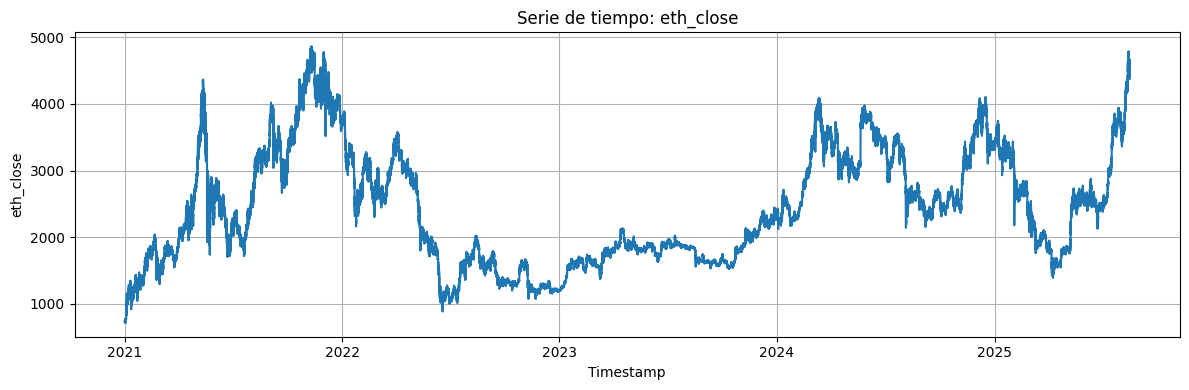

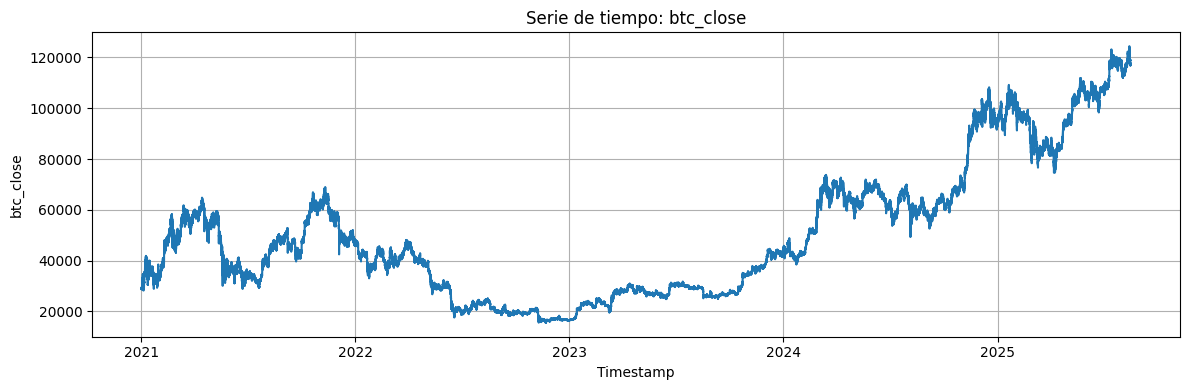

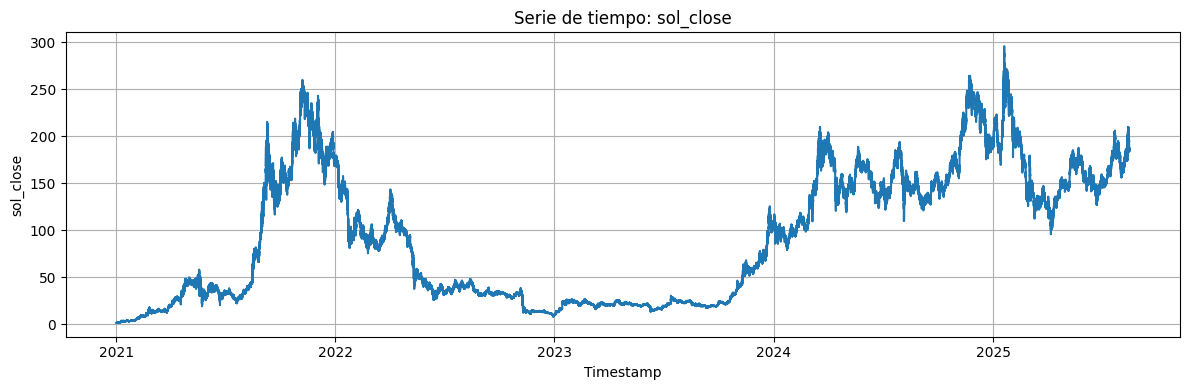

In [ ]:
import matplotlib.pyplot as plt

# Excluir la columna 'timestamp' (columna 0)
cols = mf1.columns[1:]

# Número de filas (por si querés limitar N más adelante)
N = mf1.shape[0]

# Para cada columna, graficar su serie por separado
for col in cols:
    plt.figure(figsize=(12, 4))
    plt.plot(mf1['timestamp'][:N], mf1[col][:N])
    plt.title(f'Serie de tiempo: {col}')
    plt.xlabel('Timestamp')
    plt.ylabel(col)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [ ]:
import numpy as np

float32_cols = mf1.select_dtypes(include=["float32"]).columns
mf1[[f"{c}_ln" for c in float32_cols]] = np.log(mf1[float32_cols])

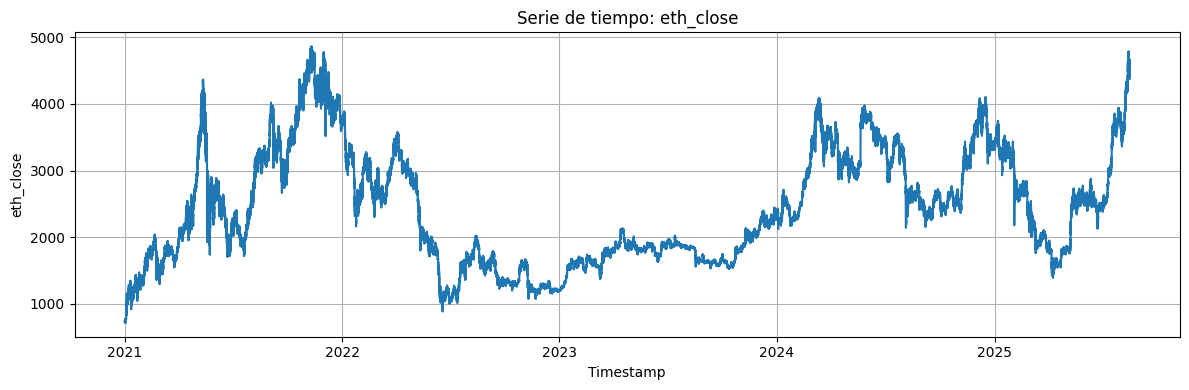

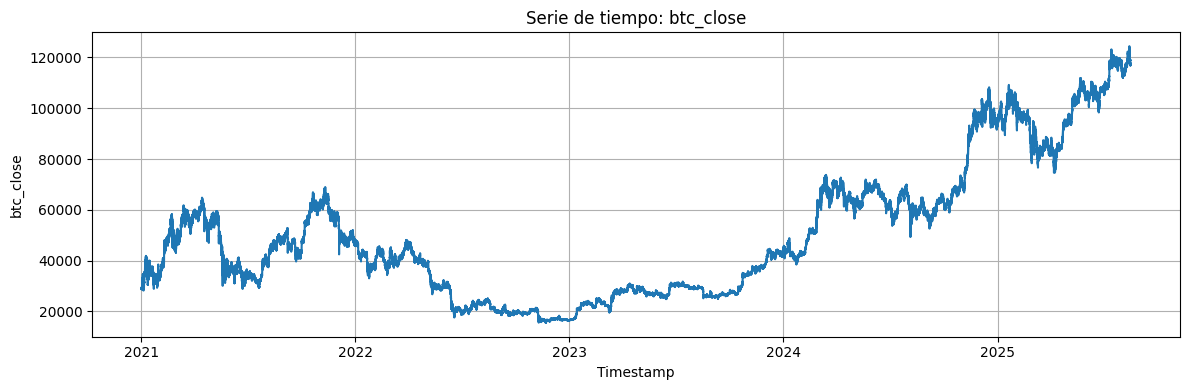

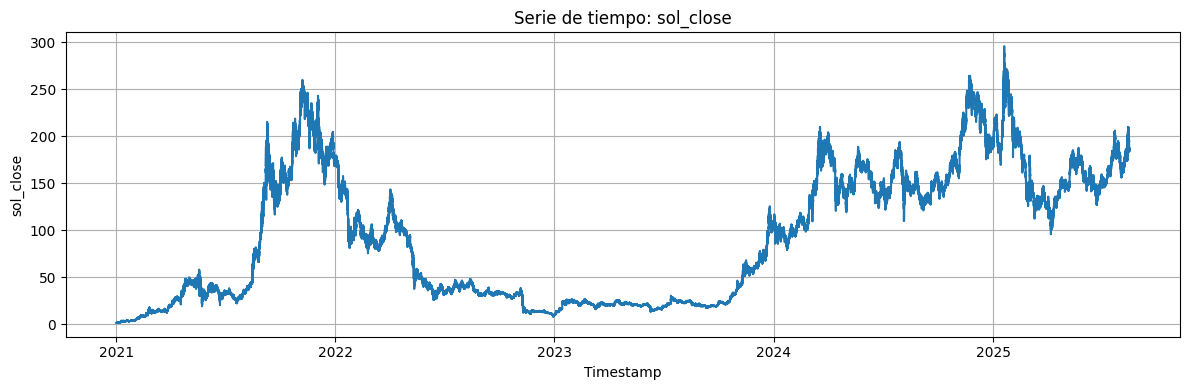

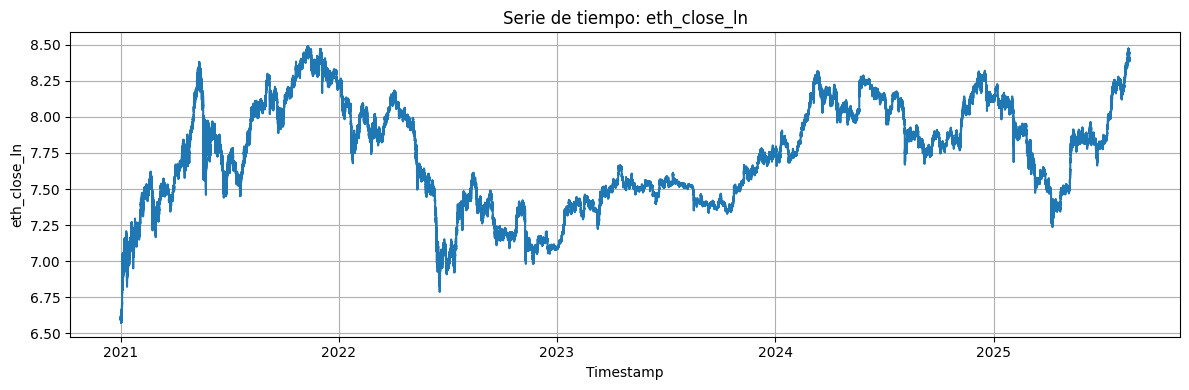

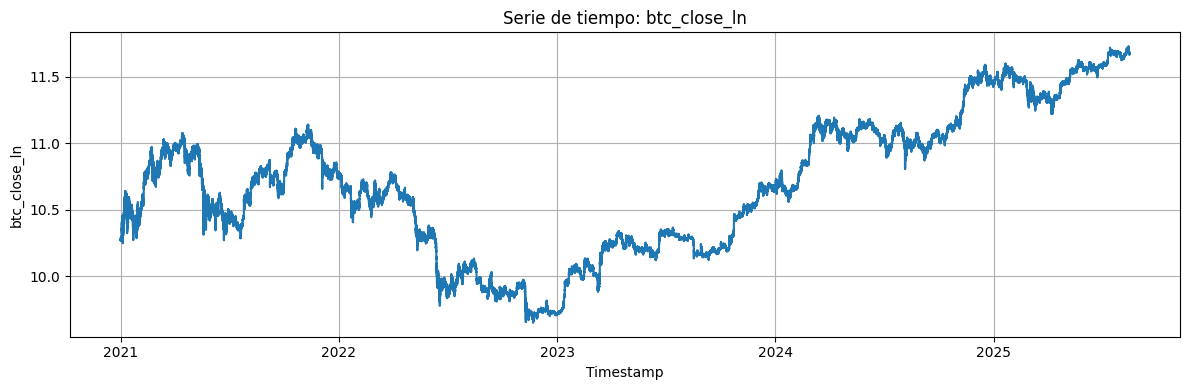

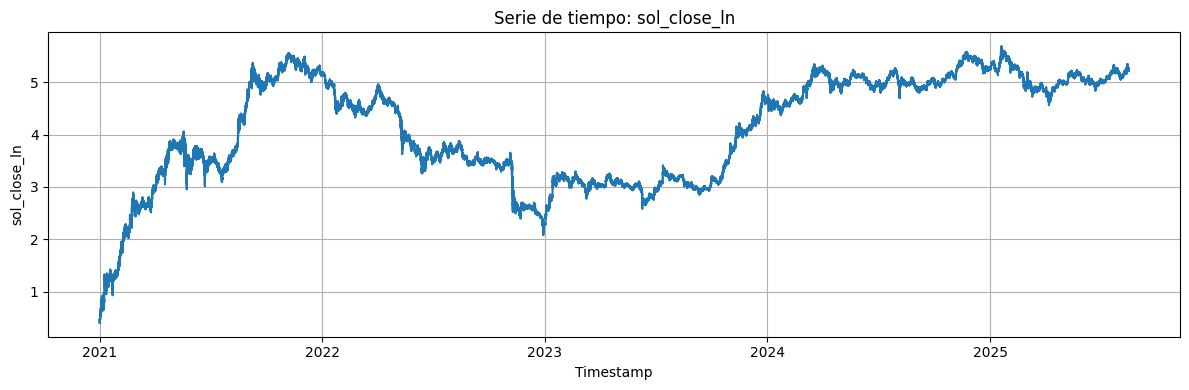

In [ ]:
import matplotlib.pyplot as plt

# Excluir la columna 'timestamp' (columna 0)
cols = mf1.columns[1:]

# Número de filas (por si querés limitar N más adelante)
N = mf1.shape[0]

# Para cada columna, graficar su serie por separado
for col in cols:
    plt.figure(figsize=(12, 4))
    plt.plot(mf1['timestamp'][:N], mf1[col][:N])
    plt.title(f'Serie de tiempo: {col}')
    plt.xlabel('Timestamp')
    plt.ylabel(col)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [ ]:
mf1['dia'] = (((pd.to_datetime(mf1['timestamp'], errors='coerce').dt.dayofweek + 1) % 7) + 1).astype('int32')
mf1['hora_str'] = mf1['timestamp'].dt.strftime('%H:%M:%S')
mf1['hora_time'] = mf1['timestamp'].dt.time
mf1['hour']   = mf1['timestamp'].dt.hour
mf1['minute'] = mf1['timestamp'].dt.minute

In [ ]:
mf1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2429647 entries, 0 to 2429646
Data columns (total 13 columns):
 #   Column        Dtype         
---  ------        -----         
 0   timestamp     datetime64[ns]
 1   eth_close     float32       
 2   btc_close     float32       
 3   sol_close     float32       
 4   eth_close_ln  float32       
 5   btc_close_ln  float32       
 6   sol_close_ln  float32       
 7   dia           int32         
 8   hora_str      object        
 9   hora_time     object        
 10  hour          int32         
 11  minute        int32         
 12  second        int32         
dtypes: datetime64[ns](1), float32(6), int32(4), object(2)
memory usage: 148.3+ MB


In [68]:
mf1.tail()

,timestamp,eth_close,btc_close,sol_close,eth_close_ln,btc_close_ln,sol_close_ln,dia,hora_str,hora_time,hour,minute,second
2429642,2025-08-15 23:55:00,4429.750000,117259.929688,185.550003,8.396098,11.672149,5.223324,6,23:55:00,23:55:00,23,55,0
2429643,2025-08-15 23:56:00,4434.799805,117323.468750,185.639999,8.397238,11.672690,5.223809,6,23:56:00,23:56:00,23,56,0
2429644,2025-08-15 23:57:00,4434.680176,117323.468750,185.649994,8.397211,11.672690,5.223863,6,23:57:00,23:57:00,23,57,0
2429645,2025-08-15 23:58:00,4436.740234,117322.640625,185.669998,8.397676,11.672683,5.223971,6,23:58:00,23:58:00,23,58,0
2429646,2025-08-15 23:59:00,4439.470215,117342.046875,185.720001,8.398291,11.672849,5.224240,6,23:59:00,23:59:00,23,59,0


In [100]:
print(mf1.columns.tolist())

['timestamp', 'eth_close', 'btc_close', 'sol_close', 'eth_close_ln', 'btc_close_ln', 'sol_close_ln', 'dia', 'hora_str', 'hora_time', 'hour', 'minute', 'second']
